# Tutorial 4 - Graph Coloring Solver

In this notebook, we are going to implement a graph coloring algorithm based on a MIS solver for a practical problem of sharing a bandwidth of frequencies for a network of antennas.

In [1]:
# imports
from mis.coloring import GraphColoringSolver
from mis.data import DataLoader
from pathlib import Path
from mis import MethodType, SolverConfig

## Importing our dataset

The practical dataset of interest is the placement of 5G antennas in Paris that can be found in the `antenna_Paris.csv` file. A set of antennas are distributed over the city with a specific coverage range. Therefore, some antennas will be in range of each other and cannot share the same frequency.

In [2]:
loader = DataLoader()
loader.load_from_csv_coordinates(Path('./datasets/coloring/antenna_Paris.csv'))

## Representing our problem instance

The first step is to represent the problem by a graph. In this case, each node represents an antenna, with an edge between two if they are in the range of each other. For the sake of simplicity, we will reduce the graph size by considering only antennas within a constant range R, set to 1.2 km.

In [3]:
instance = loader.build_mis_instance_from_coordinates(antenna_range=1.2)

Let's visualize our dataset :

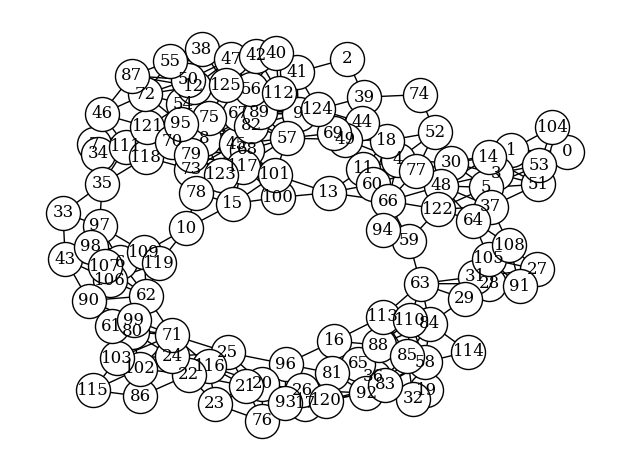

In [4]:
instance.draw()

## Solving the Graph Coloring Problem

We will use the greedy heuristic algorithm described in [Appendix A](https://arxiv.org/pdf/2301.02637) to find a coloring of the graph using MIS output. 

The algorithm starts with a set $S$ of all the nodes in the graph, and at each iteration it searches for a maximum independent set of nodes of the subgraph formed by the nodes currently in $S$, colors all of the nodes of the MIS in the same color, then removes them from $S$. The operation is repeated until $S$ is empty.


### Using a classical solver
We will first solve the coloring problem using the standard classical and heuristic [MIS solver in Networkx](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.approximation.clique.maximum_independent_set.html). As it is heuristic and non-deterministic, this solver does not guarantee an optimal solution.

preprocessing - current kernel size is 126
preprocessing - current kernel size is 42
preprocessing - current kernel size is 10
preprocessing - current kernel size is 1
preprocessing - complete
preprocessing - current kernel size is 95
preprocessing - current kernel size is 7
preprocessing - complete
preprocessing - current kernel size is 68
preprocessing - current kernel size is 9
preprocessing - complete
preprocessing - current kernel size is 49
preprocessing - current kernel size is 6
preprocessing - complete
preprocessing - current kernel size is 31
preprocessing - current kernel size is 2
preprocessing - complete
preprocessing - current kernel size is 16
preprocessing - complete
preprocessing - current kernel size is 5
preprocessing - complete
preprocessing - current kernel size is 2
preprocessing - complete
[1, 2, 0, 4, 5, 5, 4, 1, 7, 5, 1, 3, 4, 0, 1, 2, 3, 3, 0, 0, 4, 6, 2, 1, 0, 1, 2, 0, 3, 0, 0, 5, 2, 1, 2, 0, 0, 1, 1, 1, 0, 4, 2, 0, 3, 5, 0, 5, 3, 4, 3, 0, 1, 3, 6, 0, 1, 1, 4

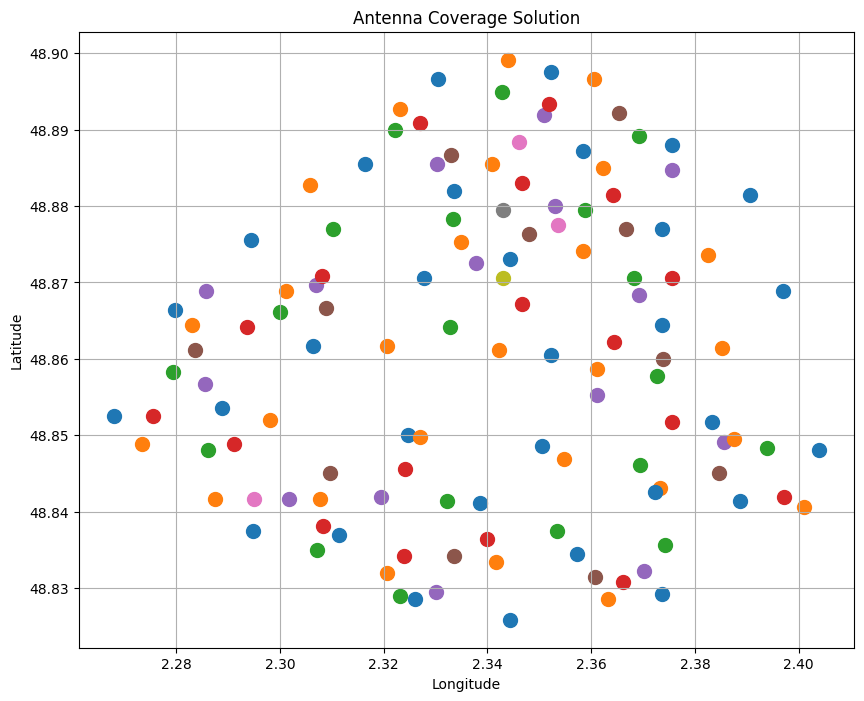

In [5]:
from mis.pipeline.kernelization import Kernelization


solver = GraphColoringSolver(loader, 1.2, SolverConfig(
    method = MethodType.EAGER,
    max_iterations=1,
))
solver.solve()
solver.visualize_solution()
print(solver.colors)   
print(f"Number of colors used: {solver.colors_count}")

The array `solver.colors` represents the group assigned to each antenna by the algorithm, such that all the antennas of the same group can share the same frequency without interfering with each other.

### Using the quantum SDK QuTiP
We will now use a quantum solver to solve the MIS instances used by our coloring algorithm, please refer to tutorial 1a for more details about the solver. 

preprocessing - current kernel size is 126
preprocessing - current kernel size is 42
preprocessing - current kernel size is 10
preprocessing - current kernel size is 1
preprocessing - complete
preprocessing - current kernel size is 95
preprocessing - current kernel size is 7
preprocessing - complete
preprocessing - current kernel size is 68
preprocessing - current kernel size is 9
preprocessing - complete
preprocessing - current kernel size is 49
preprocessing - current kernel size is 6
preprocessing - complete
preprocessing - current kernel size is 31
preprocessing - current kernel size is 2
preprocessing - complete
preprocessing - current kernel size is 16
preprocessing - complete
preprocessing - current kernel size is 5
preprocessing - complete
preprocessing - current kernel size is 2
preprocessing - complete
[1, 2, 0, 4, 5, 5, 4, 1, 7, 5, 1, 3, 4, 0, 1, 2, 3, 3, 0, 0, 4, 6, 2, 1, 0, 1, 2, 0, 3, 0, 0, 5, 2, 1, 2, 0, 0, 1, 1, 1, 0, 4, 2, 0, 3, 5, 0, 5, 3, 4, 3, 0, 1, 3, 6, 0, 1, 1, 4

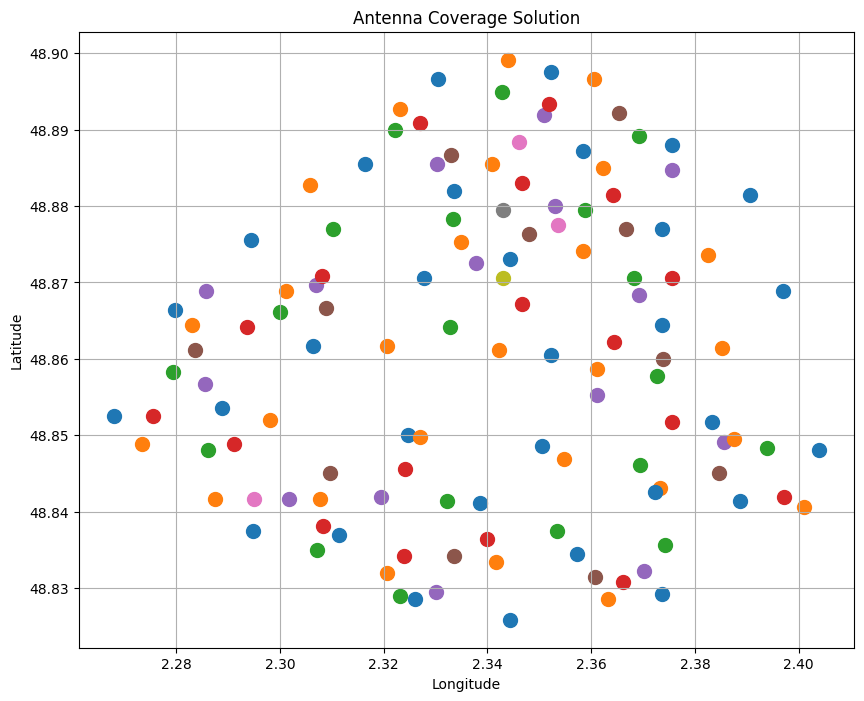

In [6]:
from mis.pipeline.maximization import Maximization
from mis import BackendConfig, BackendType

backend_config = BackendConfig(
    backend = BackendType.QUTIP
)

solver = GraphColoringSolver(loader, 1.2, SolverConfig(
    method = MethodType.EAGER,
    backend = backend_config,
    max_iterations=1
))
solver.solve()
solver.visualize_solution()
print(solver.colors)   
print(f"Number of colors used: {solver.colors_count}")

### Applying Pre and Post Processors

Performs optimizations before and after running the Quantum solver in order to enhance the quality of the results given by the algorithm.

preprocessing - current kernel size is 126
preprocessing - current kernel size is 42
preprocessing - current kernel size is 10
preprocessing - current kernel size is 1
preprocessing - complete
preprocessing - current kernel size is 95
preprocessing - current kernel size is 7
preprocessing - complete
preprocessing - current kernel size is 68
preprocessing - current kernel size is 9
preprocessing - complete
preprocessing - current kernel size is 49
preprocessing - current kernel size is 6
preprocessing - complete
preprocessing - current kernel size is 31
preprocessing - current kernel size is 2
preprocessing - complete
preprocessing - current kernel size is 16
preprocessing - complete
preprocessing - current kernel size is 5
preprocessing - complete
preprocessing - current kernel size is 2
preprocessing - complete
[1, 2, 0, 4, 5, 5, 4, 1, 7, 5, 1, 3, 4, 0, 1, 2, 3, 3, 0, 0, 4, 6, 2, 1, 0, 1, 2, 0, 3, 0, 0, 5, 2, 1, 2, 0, 0, 1, 1, 1, 0, 4, 2, 0, 3, 5, 0, 5, 3, 4, 3, 0, 1, 3, 6, 0, 1, 1, 4

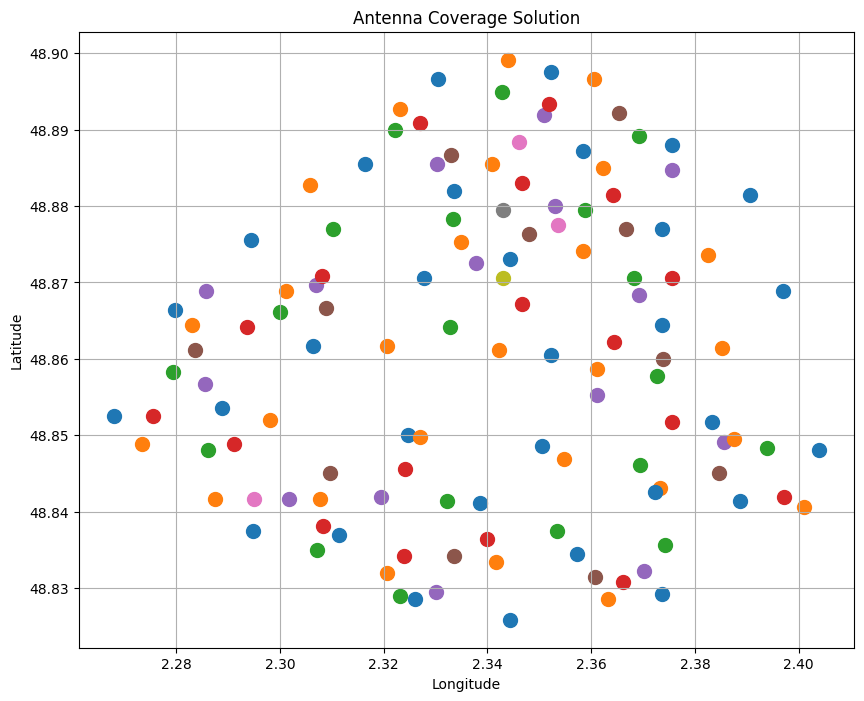

In [7]:


solver = GraphColoringSolver(loader, 1.2, SolverConfig(
    method = MethodType.EAGER,
    backend = backend_config,
    max_iterations = 1,
    preprocessor = lambda config, graph: Kernelization(config, graph),
    postprocessor = lambda config: Maximization(config)
))
solver.solve()
solver.visualize_solution()
print(solver.colors)   
print(f"Number of colors used: {solver.colors_count}")

## Enhancing our algorithm

We now explore further improvements to the MIS-based coloring algorithm.

### Color Reduction

Note that the approach we are using is a greedy heuristic algorithm, that does not necessarily give the optimal solution, let's look at an example where it is more obvious.

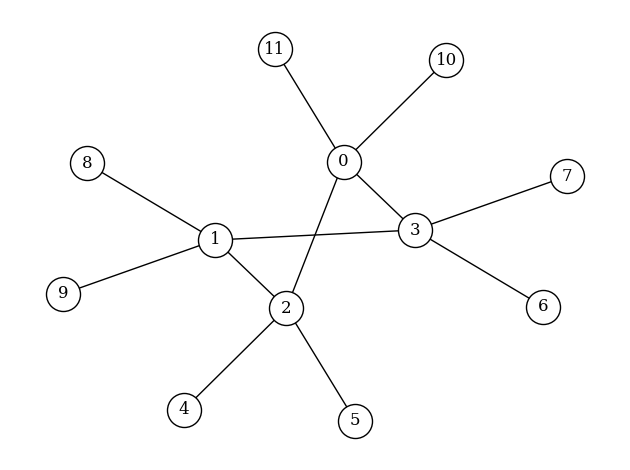

In [8]:
loader_2 = DataLoader()
loader_2.load_from_csv_coordinates(Path('./datasets/coloring/counterexample_1.csv'))
instance = loader_2.build_mis_instance_from_coordinates(antenna_range=112)
instance.draw()

preprocessing - current kernel size is 12
preprocessing - complete
preprocessing - current kernel size is 4
preprocessing - current kernel size is 1
preprocessing - complete
preprocessing - current kernel size is 2
preprocessing - complete
[2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Number of colors used: 3


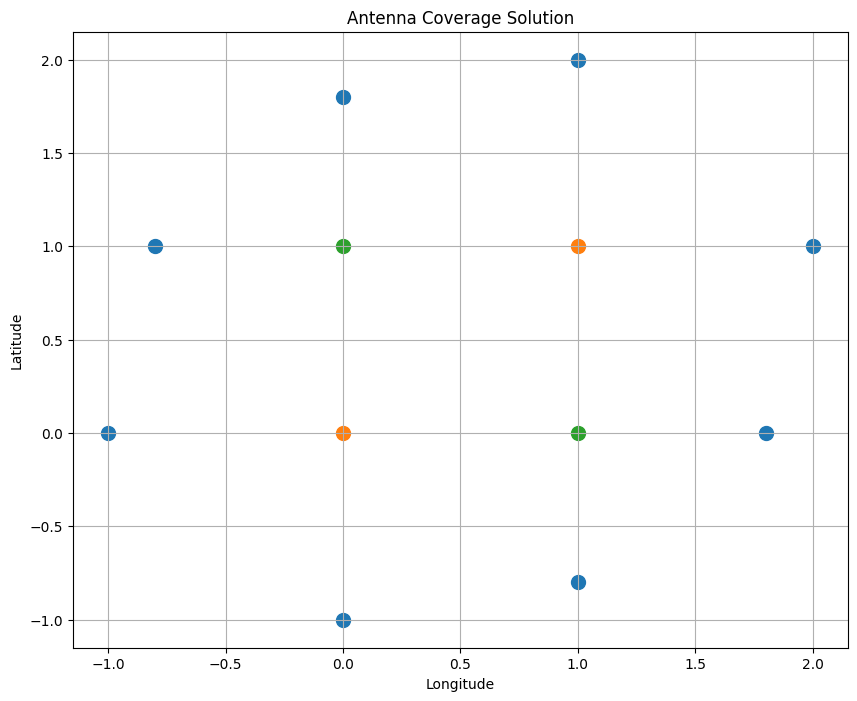

In [9]:
solver_2 = GraphColoringSolver(loader_2, 112, SolverConfig(
    method = MethodType.EAGER,
    max_iterations=1
))
solver_2.solve()
solver_2.visualize_solution()
print(solver_2.colors)   
print(f"Number of colors used: {solver_2.colors_count}")

Actually, the previous graph is [bipartite](https://en.wikipedia.org/wiki/Bipartite_graph) as it has no odd cycles, hence allowing a coloring with only two colors. It follows that our previous coloring is not optimal. We can actually improve the result of the solver using some post-processing, which involves trying to recolor every antenna of some color with an already existing colors, and if succesful, will reduce the numeber of colors.

[2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Number of colors used: 3


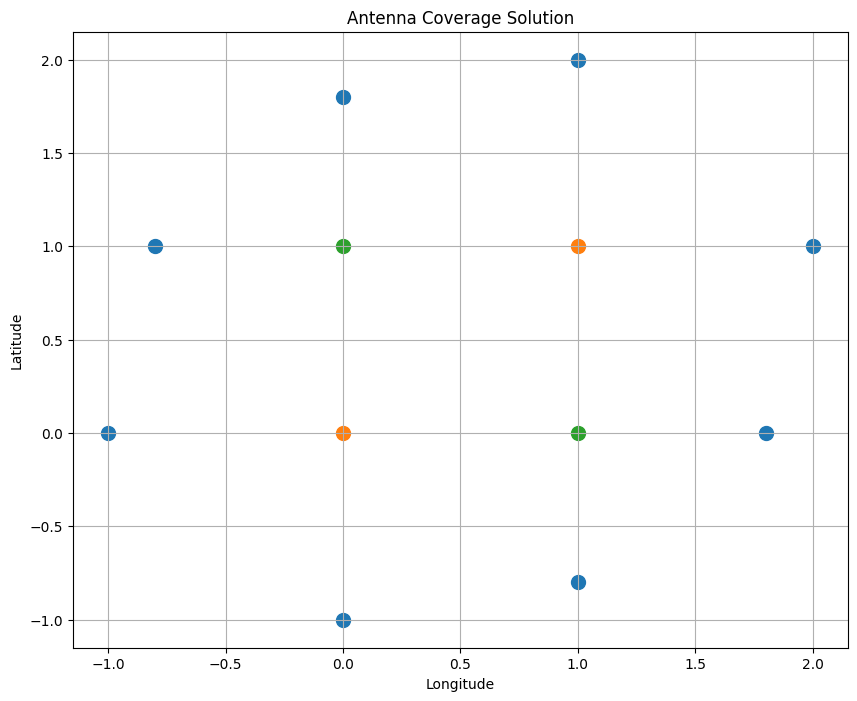

In [10]:
solver_2.reduce_colors()
solver_2.visualize_solution()
print(solver_2.colors)   
print(f"Number of colors used: {solver_2.colors_count}")

It seems that this approach successfully worked in this case, what about our original dataset ?

[0, 1, 2, 3, 2, 4, 5, 0, 2, 0, 1, 2, 1, 3, 0, 1, 2, 3, 4, 1, 3, 2, 4, 0, 4, 0, 1, 1, 2, 3, 2, 4, 5, 6, 0, 1, 3, 2, 5, 2, 7, 3, 1, 0, 7, 2, 1, 4, 5, 6, 0, 6, 4, 7, 0, 1, 4, 5, 0, 3, 7, 0, 1, 2, 4, 1, 0, 3, 5, 2, 3, 0, 2, 0, 3, 1, 2, 0, 3, 4, 0, 0, 1, 2, 3, 4, 0, 0, 5, 6, 1, 2, 3, 5, 6, 1, 1, 4, 2, 3, 0, 1, 4, 2, 5, 1, 2, 0, 3, 4, 5, 1, 3, 2, 0, 1, 0, 0, 0, 1, 0, 1, 0, 3, 4, 0]
Number of colors used: 8


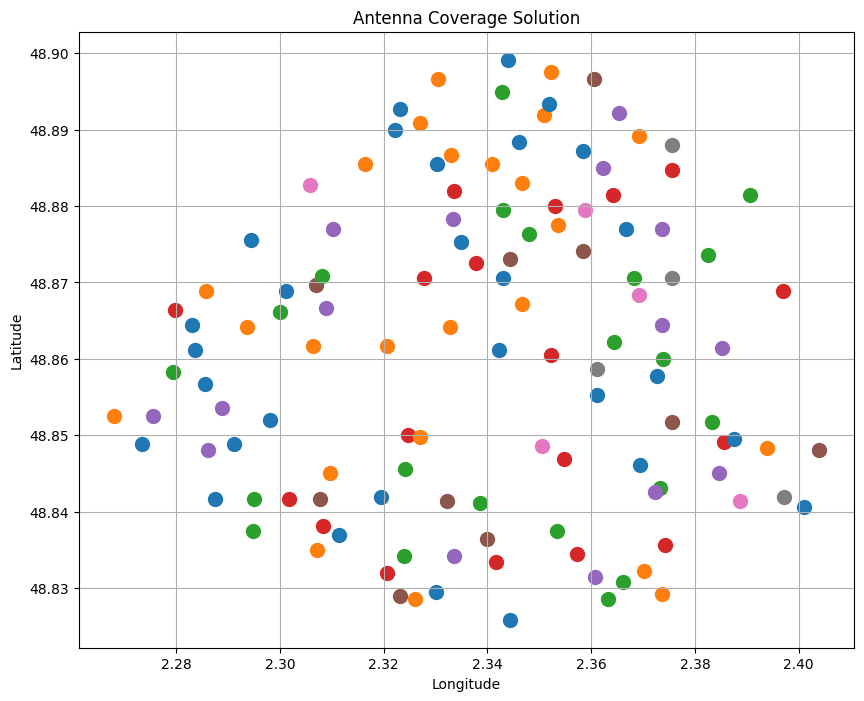

In [11]:
solver.reduce_colors()
solver.visualize_solution()
print(solver.colors)   
print(f"Number of colors used: {solver.colors_count}")

We can see that it worked, reducing indeed the total number of colors to 8.

### Node Degree Segmentation

Let's try to improve more the algorithm, by preprocessing the graph.
We first split the antennas into two groups, those with many antennas in the their range, and those with less. More formally, we will after fixing a threshold, split the nodes of the graph those with a degree higher than the threshold, and the others, then solve the coloring problem on each set, and finally join the results with the `reduce_colors` method.

preprocessing - current kernel size is 4
preprocessing - complete
preprocessing - current kernel size is 122
preprocessing - current kernel size is 42
preprocessing - current kernel size is 10
preprocessing - current kernel size is 1
preprocessing - complete
preprocessing - current kernel size is 91
preprocessing - current kernel size is 11
preprocessing - current kernel size is 1
preprocessing - complete
preprocessing - current kernel size is 64
preprocessing - current kernel size is 7
preprocessing - complete
preprocessing - current kernel size is 44
preprocessing - current kernel size is 2
preprocessing - complete
preprocessing - current kernel size is 29
preprocessing - current kernel size is 2
preprocessing - complete
preprocessing - current kernel size is 16
preprocessing - current kernel size is 1
preprocessing - complete
preprocessing - current kernel size is 6
preprocessing - complete
[1, 2, 0, 3, 0, 1, 4, 5, 3, 0, 1, 1, 2, 0, 1, 0, 2, 0, 3, 0, 3, 2, 4, 1, 5, 0, 1, 1, 2, 3, 2,

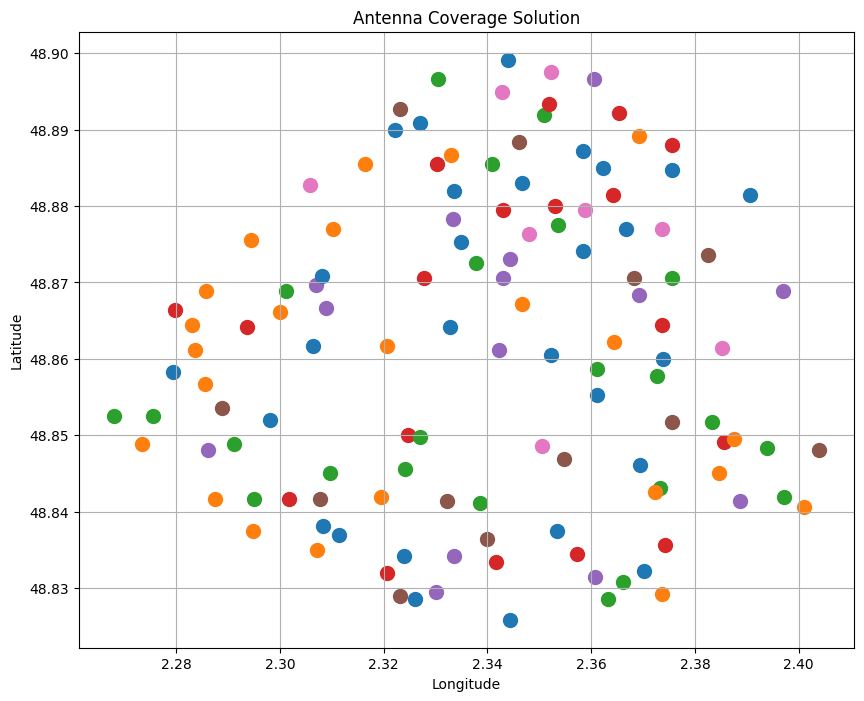

In [12]:
solver_3 = GraphColoringSolver(loader, 1.2, SolverConfig(
    method = MethodType.EAGER,
    max_iterations=1
))
sets = solver_3.split_antennas_by_degree(2) # setting the threshold to 2
solver_3.solve(antennas=sets[0])
solver_3.solve(antennas=sets[1], is_second_coloring=True)
solver_3.reduce_colors()
solver_3.visualize_solution()
print(solver_3.colors)   
print(f"Number of colors used: {solver_3.colors_count}")
print(solver_3.check_solution())